In [93]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [94]:
X = torch.tensor([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]],dtype=torch.float32)

y = torch.tensor([[0],
                  [1],
                  [1],
                  [0]],dtype=torch.float32)

In [95]:
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet,self).__init__()
        self.hidden = nn.Linear(2,4) # 2 input to 4 hidden layer
        self.output = nn.Linear(4,1) # 4 hidden to 1 outpur layer
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        x = self.sigmoid(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x


In [96]:
torch.manual_seed(42)
model = XORNet()


In [97]:
loss = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(),lr = 2.0)

In [98]:
# Training loop 
print("Training Model")
print("-"*50)
loss_history = []

for i in range(10000):
    # forward pass
    predicitions = model(X)
    loss_model  = loss(predicitions,y)
    loss_history.append(loss_model.item())

    optimizer.zero_grad() # clear pervious grads
    loss_model.backward() # compute gradient (backpropagation)
    optimizer.step() # update weights

    if(i % 2000 == 0):
        print(f"iteration: {i:5d} | Loss:{loss_model.item():.6f}")

print("-"*50)
print(f"iteration: {10000:5d} | Loss:{loss_history[-1]:.6f}")


Training Model
--------------------------------------------------
iteration:     0 | Loss:0.286560
iteration:  2000 | Loss:0.000779
iteration:  4000 | Loss:0.000298
iteration:  6000 | Loss:0.000179
iteration:  8000 | Loss:0.000127
--------------------------------------------------
iteration: 10000 | Loss:0.000098


In [99]:
print("Final Predictions")
print("-"*50)
with torch.inference_mode():
    final_preds = model(X)
    for i in range(len(X)):
        pred = final_preds[i].item()
        print(f"Input: {X[i]} → Prediction: {pred:.4f} (Target: {y[i][0]})")

Final Predictions
--------------------------------------------------
Input: tensor([0., 0.]) → Prediction: 0.0091 (Target: 0.0)
Input: tensor([0., 1.]) → Prediction: 0.9890 (Target: 1.0)
Input: tensor([1., 0.]) → Prediction: 0.9913 (Target: 1.0)
Input: tensor([1., 1.]) → Prediction: 0.0105 (Target: 0.0)


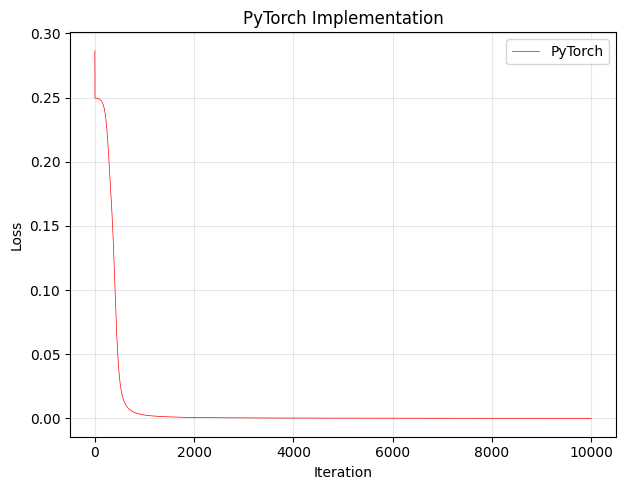

   PyTorch just automates the gradient calculations.


In [100]:
# Compare loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.plot(loss_history, 'r-', linewidth=0.5, label='PyTorch')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('PyTorch Implementation')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


print("   PyTorch just automates the gradient calculations.")